## Homework 4

A x = b with x0 = [0,0,0]
--------------------------------------------------
tolerance =    1e-03
  Jacobi      iterations =      4   x = [ 3.0000225  -2.50000266  6.99998104]
  Gauss-Seidel iterations =      4   x = [ 3.00000035 -2.50000004  6.99999999]
tolerance =    1e-03
  Jacobi      iterations =      4   x = [ 3.0000225  -2.50000266  6.99998104]
  Gauss-Seidel iterations =      4   x = [ 3.00000035 -2.50000004  6.99999999]
tolerance =    1e-03
  Jacobi      iterations =      4   x = [ 3.0000225  -2.50000266  6.99998104]
  Gauss-Seidel iterations =      4   x = [ 3.00000035 -2.50000004  6.99999999]


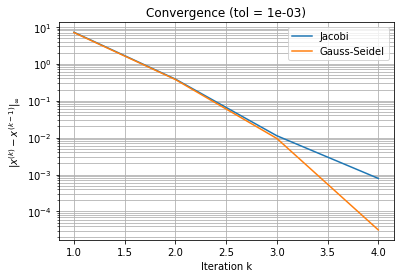

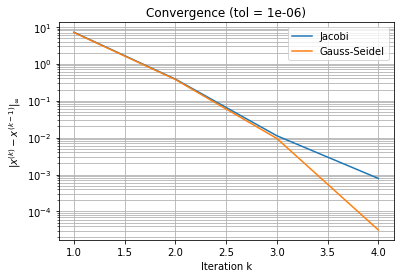

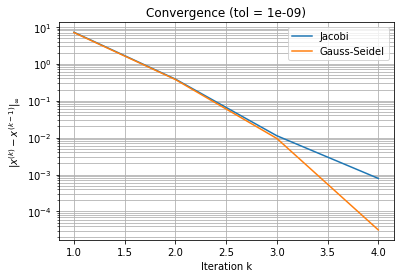

In [14]:
import numpy as np
import matplotlib.pyplot as plt


A = np.array([
    [3.0,  -0.1, -0.2],
    [0.1,   7.0, -0.3],
    [0.3,  -0.2, 10.0]
])
b = np.array([7.85, -19.3, 71.4])

x0 = np.array([0.0, 0.0, 0.0])


def jacobi(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    for k in range(max_iterations):
        x_new = np.zeros_like(x)
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]
        # Check for convergence
        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            return x_new, k
        x = x_new
    return x, max_iterations


def gauss_seidel(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()

    for k in range(max_iterations):
        x_new = x.copy()

        for i in range(n):
            s1 = sum(A[i][j] * x_new[j] for j in range(i))          # updated values
            s2 = sum(A[i][j] * x[j] for j in range(i + 1, n))       # old values
            x_new[i] = (b[i] - s1 - s2) / A[i][i]

        # Check for convergence
        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            return x_new, k

        x = x_new

    return x, max_iterations


def jacobi_with_history(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    errors = []
    for k in range(max_iterations):
        x_new = np.zeros_like(x)
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]

        err = np.linalg.norm(x_new - x, ord=np.inf)
        errors.append(err)

        if err < tol:
            return x_new, k + 1, np.array(errors)   # iterations as a human count

        x = x_new

    return x, max_iterations, np.array(errors)

def gauss_seidel_with_history(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    errors = []

    for k in range(max_iterations):
        x_new = x.copy()

        for i in range(n):
            s1 = sum(A[i][j] * x_new[j] for j in range(i))
            s2 = sum(A[i][j] * x[j] for j in range(i + 1, n))
            x_new[i] = (b[i] - s1 - s2) / A[i][i]

        err = np.linalg.norm(x_new - x, ord=np.inf)
        errors.append(err)

        if err < tol:
            return x_new, k + 1, np.array(errors)

        x = x_new

    return x, max_iterations, np.array(errors)

tolerances = [1e-3, 1e-6, 1e-9]
max_iterations = 100000

print("A x = b with x0 = [0,0,0]")
print("--------------------------------------------------")
for tolerance in tolerances:
    xj, itj, ej = jacobi_with_history(A, b, x0, tol, max_iterations)
    xg, itg, eg = gauss_seidel_with_history(A, b, x0, tol, max_iterations)

    print(f"tolerance = {tol:>8.0e}")
    print(f"  Jacobi      iterations = {itj:>6d}   x = {xj}")
    print(f"  Gauss-Seidel iterations = {itg:>6d}   x = {xg}")

    
    # AI USED TO HELP MAKE NICE PLOTS
    
    plt.figure()
    plt.semilogy(range(1, len(ej) + 1), ej, label="Jacobi")
    plt.semilogy(range(1, len(eg) + 1), eg, label="Gauss-Seidel")
    plt.xlabel("Iteration k")
    plt.ylabel(r"$\|x^{(k)} - x^{(k-1)}\|_{\infty}$")
    plt.title(f"Convergence (tol = {tolerance:.0e})")
    plt.grid(True, which="both")
    plt.legend()

plt.show()